In [2]:
#with RF Score ,results analysis
import os
import pandas as pd
import numpy as np

# 1. Load the raw data from the checkpoint file we streamed to disk
checkpoint_file = "hpc/02042026/docking_checkpoint.csv"

if not os.path.exists(checkpoint_file):
    raise RuntimeError("Checkpoint file not found. No docking was performed.")
    
raw_df = pd.read_csv(checkpoint_file)

# 2. Filter for successful results (Replacing your 'valid' list logic)
# We use pandas filtering instead of list comprehension
df_valid = raw_df[
    (raw_df["Status"] == "SUCCESS") & 
    (raw_df["Best_affinity_kcal_mol"].notna())
].copy()

if len(df_valid) < 2:
    raise RuntimeError("Not enough successful docking results for ROC analysis.")

# 3. Validation Counts
# Assuming 'Is_active' column exists (1 for active, 0 for decoy)
n_act_success = (df_valid["Is_active"] == 1).sum()
n_dec_success = (df_valid["Is_active"] == 0).sum()

print(f"  Valid results: {n_act_success} actives + {n_dec_success} decoys = {len(df_valid)} total")

if n_act_success == 0 or n_dec_success == 0:
    raise RuntimeError("Need at least 1 active AND 1 decoy with successful docking for ROC.")

# 4. Handle RF-Score edge cases
if 'RF_Score_pKd' in df_valid.columns:
    df_valid['RF_Score_pKd'] = pd.to_numeric(df_valid['RF_Score_pKd'], errors='coerce').fillna(0.0)
else:
    df_valid['RF_Score_pKd'] = 0.0

# 5. Calculate Ranks for Consensus Scoring
# rank_vina: Lower kcal/mol is better (1 is most negative)
df_valid['rank_vina'] = df_valid['Best_affinity_kcal_mol'].rank(method='min', ascending=True)

# rank_rf: Higher pKd is better (1 is highest value)
df_valid['rank_rf'] = df_valid['RF_Score_pKd'].rank(method='min', ascending=False)

# 6. Consensus Score: Rank Product (Lower is better)
# sqrt(rank1 * rank2) is a standard way to normalize rank products
df_valid['Consensus_Score'] = np.sqrt(df_valid['rank_vina'] * df_valid['rank_rf'])

# 7. Final Sort and Save
df_final = df_valid.sort_values("Consensus_Score", ascending=True)

  Valid results: 183 actives + 7407 decoys = 7590 total


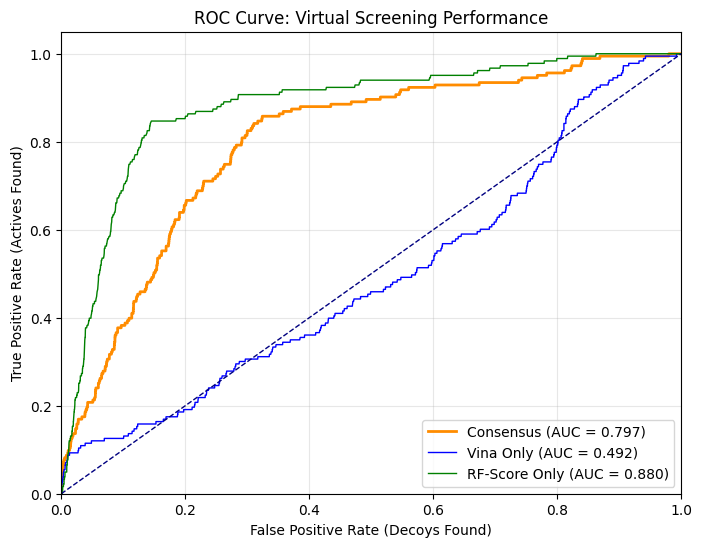

ROC AUC (Consensus): 0.7974


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Prepare Scores for ROC
# ROC functions expect higher values = better. 
# Since Consensus and Vina are "Lower is better", we negate them.
y_true = df_final['Is_active']
scores_consensus = -df_final['Consensus_Score']
scores_vina      = -df_final['Best_affinity_kcal_mol']
scores_rf        =  df_final['RF_Score_pKd'] # Already "Higher is better"

# 2. Calculate ROC Metrics
fpr_c, tpr_c, _ = roc_curve(y_true, scores_consensus)
roc_auc_c = auc(fpr_c, tpr_c)

fpr_v, tpr_v, _ = roc_curve(y_true, scores_vina)
roc_auc_v = auc(fpr_v, tpr_v)

fpr_rf, tpr_rf, _ = roc_curve(y_true, scores_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 3. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_c, tpr_c, color='darkorange', lw=2, label=f'Consensus (AUC = {roc_auc_c:.3f})')
plt.plot(fpr_v, tpr_v, color='blue',       lw=1, label=f'Vina Only (AUC = {roc_auc_v:.3f})')
plt.plot(fpr_rf, tpr_rf, color='green',     lw=1, label=f'RF-Score Only (AUC = {roc_auc_rf:.3f})')

# Random Chance Line
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Decoys Found)')
plt.ylabel('True Positive Rate (Actives Found)')
plt.title('ROC Curve: Virtual Screening Performance')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"ROC AUC (Consensus): {roc_auc_c:.4f}")

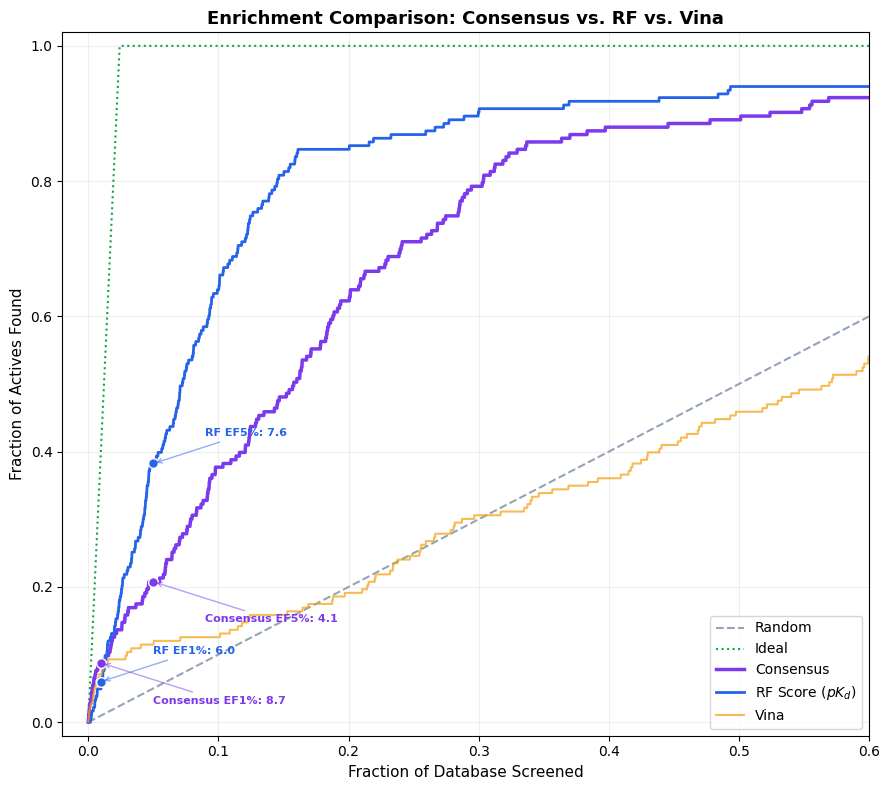

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# 1. Setup Base Variables
n_total = len(df_valid)
n_pos = n_act_success
_Ra = n_pos / n_total
frac_screened = np.arange(0, n_total + 1) / n_total

# 2. Calculate Cumulative Actives
# Consensus (Rank Product)
sorted_lab_consensus = df_valid.sort_values("Consensus_Score", ascending=True)["Is_active"].values
frac_act_consensus = np.concatenate([[0], np.cumsum(sorted_lab_consensus) / n_pos])

# RF Only (pKd)
sorted_lab_rf = df_valid.sort_values("RF_Score_pKd", ascending=False)["Is_active"].values
frac_act_rf = np.concatenate([[0], np.cumsum(sorted_lab_rf) / n_pos])

# Vina Only (kcal/mol)
sorted_lab_vina = df_valid.sort_values("Best_affinity_kcal_mol", ascending=True)["Is_active"].values
frac_act_vina = np.concatenate([[0], np.cumsum(sorted_lab_vina) / n_pos])

# 3. Plotting
plt.figure(figsize=(9, 8))

# Baselines
plt.plot([0, 1], [0, 1], "--", color="#94a3b8", label="Random")
plt.plot([0, min(n_pos/n_total, 1.0), 1.0], [0, 1.0, 1.0], ":", color="#16a34a", label="Ideal")

# Method Curves
plt.plot(frac_screened, frac_act_consensus, color="#7c3aed", linewidth=2.5, label="Consensus")
plt.plot(frac_screened, frac_act_rf, color="#2563eb", linewidth=2, label="RF Score ($pK_d$)")
plt.plot(frac_screened, frac_act_vina, color="#f59e0b", linewidth=1.5, alpha=0.7, label="Vina")

# 4. Labeling 1% and 5% for BOTH methods
methods = [
    {"name": "Consensus", "labels": sorted_lab_consensus, "color": "#7c3aed", "offset": -0.06},
    {"name": "RF", "labels": sorted_lab_rf, "color": "#2563eb", "offset": 0.04}
]

for m in methods:
    for frac in [0.01, 0.05]:
        top_n = max(1, int(round(frac * n_total)))
        hits = m["labels"][:top_n].sum()
        y_pt = hits / n_pos
        ef = (hits / top_n) / _Ra if _Ra > 0 else 0
        
        # Plot point
        plt.plot(frac, y_pt, "o", color=m["color"], markersize=7, markeredgecolor="white")
        
        # Add annotation with slight offset logic to prevent overlapping
        plt.annotate(f"{m['name']} EF{frac:.0%}: {ef:.1f}",
                    xy=(frac, y_pt), 
                    xytext=(frac + 0.04, y_pt + m['offset']),
                    fontsize=8, fontweight="bold", color=m["color"],
                    arrowprops=dict(arrowstyle="->", color=m["color"], alpha=0.5))

# 5. Final Formatting
plt.xlabel("Fraction of Database Screened", fontsize=11)
plt.ylabel("Fraction of Actives Found", fontsize=11)
plt.title("Enrichment Comparison: Consensus vs. RF vs. Vina", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.xlim(-0.02, 0.6) # Zooming into the first 60% for better visibility of the "Early Enrichment"
plt.ylim(-0.02, 1.02)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.1))
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [10]:
import numpy as np

alpha = 20.0
n = len(df_valid)
n_act = n_act_success

# Function to calculate BEDROC for a given sorting
def calculate_bedroc(df, score_col, ascending=True, alpha=20.0):
    # 1. Sort the dataframe
    df_sorted = df.sort_values(score_col, ascending=ascending).reset_index(drop=True)
    
    # 2. Identify 1-based ranks of actives
    ranks_of_actives = np.where(df_sorted["Is_active"].values == 1)[0] + 1
    
    # 3. Calculate sum of exponential weights
    sum_exp = np.sum(np.exp(-alpha * (ranks_of_actives / n)))
    
    # 4. Calculate Ideal sum (actives at positions 1, 2, 3...)
    ri_ideal = np.sum(np.exp(-alpha * (np.arange(1, n_act + 1) / n)))
    
    # 5. Calculate Random sum
    ra = n_act / n
    ri_rand = (ra * (1 - np.exp(-alpha))) / (n * (1 - np.exp(-alpha/n)))
    
    # 6. Final BEDROC calculation
    bedroc_score = (sum_exp - ri_rand) / (ri_ideal - ri_rand) if (ri_ideal - ri_rand) != 0 else 0.0
    return bedroc_score

# --- Calculate for all 3 ---

# 1. Consensus (Lower Rank Product is better)
bedroc_consensus = calculate_bedroc(df_valid, "Consensus_Score", ascending=True, alpha=alpha)

# 2. RF Score (Higher pKd is better)
bedroc_rf = calculate_bedroc(df_valid, "RF_Score_pKd", ascending=False, alpha=alpha)

# 3. Vina Affinity (Lower kcal/mol is better)
bedroc_vina = calculate_bedroc(df_valid, "Best_affinity_kcal_mol", ascending=True, alpha=alpha)

# --- Print Results ---
print(f"--- BEDROC Analysis (alpha={alpha}) ---")
print(f"Consensus: {bedroc_consensus:.4f}")
print(f"RF Score:  {bedroc_rf:.4f}")
print(f"Vina:      {bedroc_vina:.4f}")

--- BEDROC Analysis (alpha=20.0) ---
Consensus: 0.2570
RF Score:  0.3936
Vina:      0.1300


In [20]:
import numpy as np
import pandas as pd

# Define the three sorting strategies
methods = [
    {"name": "Consensus     ", "col": "Consensus_Score", "ascending": True},
    {"name": "RF Score (pKd)",           "col": "RF_Score_pKd",   "ascending": False},
    {"name": "Vina (kcal/mol)",         "col": "Best_affinity_kcal_mol", "ascending": True}
]


print(f"\nTotal compounds in library: {len(df_valid)}\n")


print(f"{'Method':<25} | {'First 10 Active Ranks'}")
print("-" * 65)

for m in methods:
    # 1. Sort the dataframe by the specific method
    df_sorted = df_valid.sort_values(m["col"], ascending=m["ascending"]).reset_index(drop=True)
    
    # 2. Find the 1-based indices (ranks) where 'Is_active' == 1
    active_ranks = np.where(df_sorted["Is_active"].values == 1)[0] + 1
    
    # 3. Format and print the first 10 ranks
    ranks_str = ", ".join(map(str, active_ranks[:10]))
    print(f"{m['name']:<25} | {ranks_str}")

n_total = len(df_valid)
_Ra = n_act_success / n_total  # Base ratio of actives

print(f"\n--- Enrichment Factor Comparison ---")
print(f"{'Method':<12} | {'Frac':>6} | {'Top-N':>6} | {'Hits':>6} | {'EF':>8} | {'Max EF':>8}")
print("-" * 65)

all_ef_results = {}

for m in methods:
    # Sort the dataframe specifically for this method
    df_sorted = df_valid.sort_values(m["col"], ascending=m["ascending"])
    sorted_lab = df_sorted["Is_active"].values
    
    all_ef_results[m["name"]] = {}
    
    for frac in [0.01, 0.05]:
        top_n = max(1, int(round(frac * n_total)))
        top_labels = sorted_lab[:top_n]
        n_act_in_top = int(top_labels.sum())
        
        hits_rate = n_act_in_top / top_n
        ef = hits_rate / _Ra if _Ra > 0 else 0.0
        max_ef = (min(n_act_success, top_n) / top_n) / _Ra if _Ra > 0 else 0.0
        
        all_ef_results[m["name"]][frac] = ef
        
        print(f"{m['name']:<12} | {frac:>5.0%} | {top_n:>6} | {n_act_in_top:>6} | {ef:>8.2f} | {max_ef:>8.2f}")
    print("-" * 65)


Total compounds in library: 7590

Method                    | First 10 Active Ranks
-----------------------------------------------------------------
Consensus                 | 1, 3, 5, 7, 8, 14, 18, 19, 23, 25
RF Score (pKd)            | 14, 18, 20, 30, 38, 39, 45, 52, 53, 75
Vina (kcal/mol)           | 2, 4, 5, 9, 14, 23, 27, 32, 34, 42

--- Enrichment Factor Comparison ---
Method       |   Frac |  Top-N |   Hits |       EF |   Max EF
-----------------------------------------------------------------
Consensus      |    1% |     76 |     16 |     8.73 |    41.48
Consensus      |    5% |    380 |     38 |     4.15 |    19.97
-----------------------------------------------------------------
RF Score (pKd) |    1% |     76 |     11 |     6.00 |    41.48
RF Score (pKd) |    5% |    380 |     70 |     7.64 |    19.97
-----------------------------------------------------------------
Vina (kcal/mol) |    1% |     76 |     13 |     7.09 |    41.48
Vina (kcal/mol) |    5% |    380 |     21 |

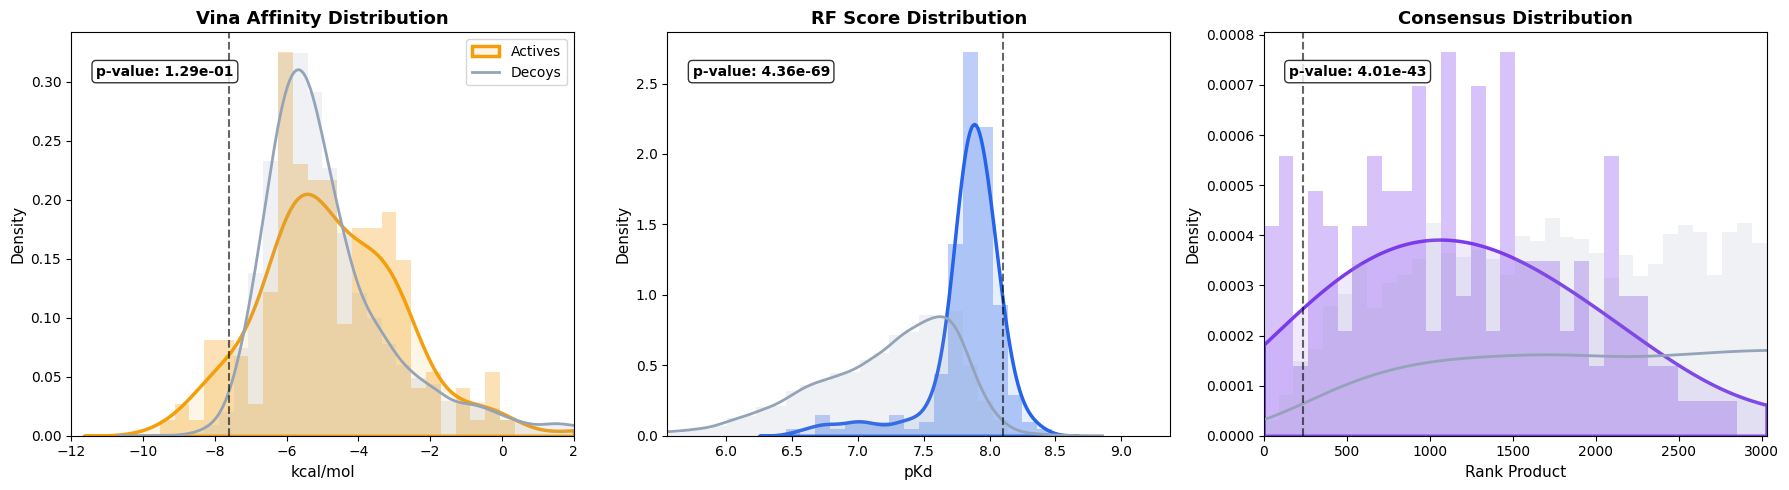

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [
    {"name": "Vina Affinity", "col": "Best_affinity_kcal_mol", "color": "#f59e0b", "better": "lower",  "unit": "kcal/mol", "range": (-12, 2)},
    {"name": "RF Score",      "col": "RF_Score_pKd",           "color": "#2563eb", "better": "higher", "unit": "pKd",         "range": (None, None)},
    {"name": "Consensus",     "col": "Consensus_Score",        "color": "#7c3aed", "better": "lower",  "unit": "Rank Product", "range": (0, None)}
]

for i, m in enumerate(methods):
    ax = axes[i]
    
    # 1. Get raw data and handle NaNs
    act_raw = df_valid[df_valid["Is_active"] == 1][m["col"]].dropna()
    dec_raw = df_valid[df_valid["Is_active"] == 0][m["col"]].dropna()
    
    # 2. CLIP DATA for Vina to ensure KDE matches Histogram
    if m["name"] == "Vina Affinity":
        # We only keep decoys in a reasonable range so the KDE isn't distorted
        act_vals = act_raw[act_raw <= 5]
        dec_vals = dec_raw[dec_raw <= 5]
        plot_range = (-12, 2)
    elif m["name"] == "Consensus":
        act_vals = act_raw
        dec_vals = dec_raw
        plot_range = (0, pd.concat([act_raw, dec_raw]).max() * 0.4)
    else:
        act_vals = act_raw
        dec_vals = dec_raw
        plot_range = (act_raw.min() - 1, act_raw.max() + 1)

    # 3. Plot KDE and Histogram using the SAME clipped data
    # 'clip' parameter in kdeplot ensures the line doesn't bleed past our limits
    sns.kdeplot(act_vals, ax=ax, color=m["color"], linewidth=2.5, label="Actives", 
                fill=True, alpha=0.1, clip=plot_range)
    sns.kdeplot(dec_vals, ax=ax, color="#94a3b8", linewidth=2, label="Decoys", 
                clip=plot_range)
    
    bins = np.linspace(plot_range[0], plot_range[1], 35)
    ax.hist(act_vals, bins=bins, density=True, alpha=0.3, color=m["color"], edgecolor="none")
    ax.hist(dec_vals, bins=bins, density=True, alpha=0.15, color="#94a3b8", edgecolor="none")

    # 4. Axes limits and Stats
    ax.set_xlim(plot_range)
    stat, p_val = mannwhitneyu(act_vals, dec_vals, alternative='two-sided')
    
    ax.text(0.05, 0.92, f"p-value: {p_val:.2e}", transform=ax.transAxes, 
            ha='left', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            fontsize=10, fontweight="bold")

    # 5. Top 1% Threshold Line
    all_vals_for_percentile = pd.concat([act_raw, dec_raw])
    if m["better"] == "lower":
        thresh = np.percentile(all_vals_for_percentile, 1)
    else:
        thresh = np.percentile(all_vals_for_percentile, 99)
    ax.axvline(thresh, color='black', linestyle='--', alpha=0.6)
    
    ax.set_title(f"{m['name']} Distribution", fontsize=13, fontweight="bold")
    ax.set_xlabel(f"{m['unit']}", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    if i == 0: ax.legend(loc='upper right')

plt.tight_layout()
plt.show()